In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import seaborn as sns
import matplotlib.pyplot as plt

### Feature engineering
For each column in cols, it adds:
- col_lag1, col_lag2: value from 1 and 2 days earlier.
- col_roll7, col_roll14: rolling mean over past 7/14 days (past-only, not using current day).
- col_diff1: day-to-day change (today - yesterday).

- It gives the model trend/history information, not just today’s raw value.

In [2]:
# -------------------------
# 1) Feature engineering
# -------------------------
def add_time_features(df: pd.DataFrame, cols, lags=(1,2), rolls=(7,14), diffs=(1,)):
    df = df.sort_values("date").copy()

    for col in cols:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

        # Past-only rolling means: shift first, then roll
        s = df[col].shift(1)
        for w in rolls:
            df[f"{col}_roll{w}"] = s.rolling(w, min_periods=max(3, w//3)).mean()

        for d in diffs:
            df[f"{col}_diff{d}"] = df[col].diff(d)

    return df

In [3]:
# -------------------------
# 2) Read Data
# -------------------------
FILE_NAME = f"./data/garmin_data_730days/garmin_data_730days.csv"
df = pd.read_csv(FILE_NAME)

# basic shape + columns
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# dtypes + non-null counts
# print("\nInfo:")
# print(df.info())

# missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
# print("\nMissing values (top):")
# print(missing_summary[missing_summary["missing_count"] > 0].head(20))

cols_to_keep = [c for c in df.columns if missing_pct[c] < 60]
df = df[cols_to_keep]

# missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(20))


# duplicates
print("\nDuplicate rows:", df.duplicated().sum())


# numeric summary
# print("\nNumeric summary:")
# print(df.describe(include=[ "number" ]).T)

# categorical/text/date-like summary
# print("\nNon-numeric summary:")
# print(df.describe(include=[ "object", "category", "bool" ]).T)

# optional: if you have a date column named 'date'
if "date" in df.columns:
    tmp = df.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    print("\nDate range:", tmp["date"].min(), "to", tmp["date"].max())
    print("Invalid dates:", tmp["date"].isna().sum())

Shape: (731, 51)

Columns:
['date', 'hrv_rmssd', 'status', 'weekly_avg', 'lastnight_5min_high', 'feedback_phrase', 'resting_hr', 'total_sleep_hr', 'deep_sleep_hr', 'light_sleep_hr', 'rem_sleep_hr', 'awake_sleep_hr', 'avg_sleep_hr', 'avg_sleep_respiration', 'avg_sleep_stress', 'sleep_score', 'sleep_quality', 'sleep_feedback', 'sleep_need_baseline', 'sleep_need_actual', 'sleep_need_feedback', 'cycle_phase', 'maxStressLevel', 'avgStressLevel', 'charged', 'drained', 'monthlyLoadAerobicLow', 'monthlyLoadAerobicHigh', 'monthlyLoadAnaerobic', 'monthlyLoadAerobicLowTargetMin', 'monthlyLoadAerobicLowTargetMax', 'monthlyLoadAerobicHighTargetMin', 'monthlyLoadAerobicHighTargetMax', 'monthlyLoadAnaerobicTargetMin', 'monthlyLoadAnaerobicTargetMax', 'trainingBalanceFeedbackPhrase', 'trainingStatus', 'weeklyTrainingLoad', 'feedback', 'dailyTrainingLoadAcute', 'acwrPercent', 'acwrStatus', 'acwrStatusFeedback', 'dailyTrainingLoadChronic', 'minTrainingLoadChronic', 'maxTrainingLoadChronic', 'dailyAcuteC

In [4]:
# -------------------------
# 3) Build dataset
# -------------------------
target = "cycle_phase"

base_cols = [
    "date",
    "hrv_rmssd", "resting_hr", #"avg_sleep_hr",
    "sleep_score", "total_sleep_hr", "deep_sleep_hr", "light_sleep_hr", "rem_sleep_hr", "awake_sleep_hr",
    "avg_sleep_stress",
    "avgStressLevel", "maxStressLevel",
    "dailyTrainingLoadChronic", "dailyTrainingLoadAcute", "acwrPercent",
    "drained", "charged",
]

base_cols = list(dict.fromkeys(base_cols))

needed = base_cols + [target]
missing = [c for c in needed if c not in df.columns]
print("Missing columns:", missing)

# df must have: date + base_cols + target
df_model = df[needed].copy()
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
df_model = df_model.sort_values("date")

# merge ovulation into fertile
df_model[target] = (
    df_model[target]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"ovulation": "fertile"})
)

print(df_model[target].value_counts(dropna=False))

print("Duplicate columns:", df_model.columns[df_model.columns.duplicated()].tolist())
print("\nColumns:")
print(df_model.columns.tolist())

df_model = add_time_features(
    df_model,
    cols=["hrv_rmssd","resting_hr","sleep_score","avgStressLevel","dailyTrainingLoadChronic"],
)

# Drop rows where label missing (keep feature NaNs for imputer)
df_model = df_model.dropna(subset=[target]).reset_index(drop=True)

# missing values
missing_count = df_model.isna().sum().sort_values(ascending=False)
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(20))

# Features: keep only numeric columns (or define explicitly)
feature_cols = [c for c in df_model.columns if c not in ["date", target]]
print("\nfeature_cols:", feature_cols)

X = df_model[feature_cols]
y = df_model[target]

# -------------------------
# 3) Time-based holdout split
# -------------------------
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

Missing columns: []
cycle_phase
luteal        272
fertile       189
menstrual     138
follicular    132
Name: count, dtype: int64
Duplicate columns: []

Columns:
['date', 'hrv_rmssd', 'resting_hr', 'sleep_score', 'total_sleep_hr', 'deep_sleep_hr', 'light_sleep_hr', 'rem_sleep_hr', 'awake_sleep_hr', 'avg_sleep_stress', 'avgStressLevel', 'maxStressLevel', 'dailyTrainingLoadChronic', 'dailyTrainingLoadAcute', 'acwrPercent', 'drained', 'charged', 'cycle_phase']

Missing values (top):
                                 missing_count  missing_pct
awake_sleep_hr                             129        17.65
hrv_rmssd_diff1                             17         2.33
sleep_score_diff1                           15         2.05
hrv_rmssd_lag2                              10         1.37
hrv_rmssd_lag1                               9         1.23
deep_sleep_hr                                9         1.23
sleep_score_lag2                             9         1.23
rem_sleep_hr                       

In [5]:
# -------------------------
# 4) Pipeline
# -------------------------
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")), # fill nan values
            ("scaler", StandardScaler()), # standardize values so that scale does not affect
        ]), numeric_features),
    ],
    remainder="drop",
)

clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clf),
])


In [6]:
# -------------------------
# 5) TimeSeries CV + grid
# -------------------------
tscv = TimeSeriesSplit(n_splits=5) # Splits data into 5 ordered train/validation folds

param_grid = {
    "clf__C": np.logspace(-3, 2, 10)  # from 0.001 to 100
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best = grid.best_estimator_

Best params: {'clf__C': np.float64(7.742636826811277)}


In [7]:
# fitted pipeline
best_pipe = grid.best_estimator_

# names of features after ColumnTransformer
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
# feat_names = X_train.columns        # if X is a DataFrame


# coef matrix: (n_classes, n_features)
W = best_pipe.named_steps["clf"].coef_
classes = best_pipe.named_steps["clf"].classes_

print(W.shape, len(feat_names), classes)

importance = np.linalg.norm(W, axis=0)          # L2 across classes
# importance = np.mean(np.abs(W), axis=0)       # alternative

rank = pd.Series(importance, index=feat_names).sort_values(ascending=False)
print(rank.head(10))

K = len(classes)
for k in range(K):
    w = pd.Series(W[k], index=feat_names).sort_values()
    print("\n==============================")
    print("Class:", classes[k])
    print("Most negative (push away):")
    print(w.head(8))
    print("\nMost positive (push toward):")
    print(w.tail(8))


(4, 41) 41 ['fertile' 'follicular' 'luteal' 'menstrual']
num__resting_hr_roll7                   4.416703
num__dailyTrainingLoadChronic_roll7     4.246099
num__dailyTrainingLoadAcute             3.346874
num__resting_hr_roll14                  3.319983
num__dailyTrainingLoadChronic           2.899574
num__dailyTrainingLoadChronic_lag1      2.791871
num__dailyTrainingLoadChronic_lag2      2.476797
num__dailyTrainingLoadChronic_roll14    2.194204
num__sleep_score_diff1                  1.916953
num__hrv_rmssd_roll7                    1.749761
dtype: float64

Class: fertile
Most negative (push away):
num__dailyTrainingLoadAcute           -2.844456
num__dailyTrainingLoadChronic_roll7   -2.614116
num__resting_hr_roll7                 -1.309568
num__hrv_rmssd_roll14                 -1.015079
num__sleep_score_diff1                -0.802918
num__dailyTrainingLoadChronic_lag2    -0.646077
num__awake_sleep_hr                   -0.437251
num__sleep_score_lag1                 -0.410747
dtype: floa

In [8]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_pipe,
    X_test, y_test,
    n_repeats=20,
    random_state=0,
    scoring="f1_weighted"
)

perm_rank = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False)
print("Top 15 permutation importances:")
print(perm_rank.head(15))


Top 15 permutation importances:
num__resting_hr_roll7                  0.199995
num__resting_hr_lag1                   0.104845
num__hrv_rmssd_roll7                   0.098173
num__dailyTrainingLoadAcute            0.096993
num__dailyTrainingLoadChronic_lag2     0.089154
num__resting_hr_roll14                 0.084019
num__hrv_rmssd_lag1                    0.082975
num__hrv_rmssd                         0.081426
num__dailyTrainingLoadChronic_roll7    0.069939
num__hrv_rmssd_diff1                   0.043421
num__sleep_score_lag1                  0.040775
num__sleep_score_roll14                0.035122
num__light_sleep_hr                    0.034572
num__resting_hr                        0.033207
num__avgStressLevel_lag1               0.029006
dtype: float64


In [9]:
# -------------------------
# 6) Evaluate
# -------------------------
y_pred = best.predict(X_test)

print(y_test.value_counts())
print(pd.Series(y_pred).value_counts())
print(classification_report(y_test, y_pred, zero_division=0))

cycle_phase
luteal        50
follicular    35
fertile       35
menstrual     27
Name: count, dtype: int64
luteal        48
menstrual     46
follicular    43
fertile       10
Name: count, dtype: int64
              precision    recall  f1-score   support

     fertile       0.40      0.11      0.18        35
  follicular       0.40      0.49      0.44        35
      luteal       0.75      0.72      0.73        50
   menstrual       0.39      0.67      0.49        27

    accuracy                           0.51       147
   macro avg       0.48      0.50      0.46       147
weighted avg       0.52      0.51      0.49       147



Text(0.5, 1.0, 'Confusion Matrix')

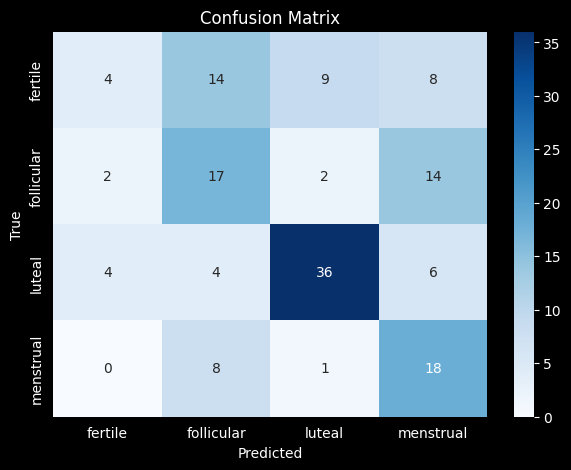

In [10]:
# 1) Confusion Matrix (Seaborn)
labels = np.unique(np.concatenate([np.array(y_test), np.array(y_pred)]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
# plt.tight_layo